**On estime maintenant la distribution du nombre de lots qui se trouvent au même endroit, donc du nombre de lots par bâtiment, comme ça quand on génèrera un lieu où une nouvelle offre apparaîtra, on saura selon quelle loi générer le nombre de lots**

In [36]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [37]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

In [38]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
"""

lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

conn.commit()
cursor.close()
conn.close()

C:\Users\quent\AppData\Local\Temp\ipykernel_7100\952115406.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)


Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


In [39]:
print(lots_adresses.columns)

Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


In [40]:
# 1. Grouper par les coordonnées
coords_group = lots_adresses.groupby(['adr_plan_x', 'adr_plan_y']).size().reset_index(name='nb_lots_meme_coord')

# 2. Fusionner ce comptage dans le DataFrame d'origine
lots_adresses = lots_adresses.merge(coords_group, on=['adr_plan_x', 'adr_plan_y'], how='left')
lots_adresses = lots_adresses[lots_adresses['nb_lots_meme_coord'].notna()]

# 3. Aperçu
print(lots_adresses[['adr_plan_x', 'adr_plan_y', 'nb_lots_meme_coord']])

         adr_plan_x  adr_plan_y  nb_lots_meme_coord
90         2.473666   48.809212                17.0
312        2.081413   49.043644                26.0
313        2.308746   48.872342                 3.0
334        2.304835   48.870710                 3.0
335        2.304835   48.870710                 3.0
...             ...         ...                 ...
2422103    2.331841   48.868195                35.0
2422109    2.275296   48.896286                81.0
2422110    2.275296   48.896286                81.0
2422111    2.275296   48.896286                81.0
2422112    2.275296   48.896286                81.0

[2326333 rows x 3 columns]


In [43]:
# 1. Grouper par coordonnées et compter les occurrences
df_coords_uniques = lots_adresses.groupby(['adr_plan_x', 'adr_plan_y']).size().reset_index(name='nb_lots')

# 2. Afficher un aperçu
print(df_coords_uniques.head())
print(f"Nombre total de groupes (coordonnées uniques) : {len(df_coords_uniques)}")

   adr_plan_x  adr_plan_y  nb_lots
0 -119.365611   38.825738        2
1 -108.749849   48.764500        1
2  -95.214923   18.446666        1
3  -94.222581   35.429876        2
4  -90.908254   46.493621        2
Nombre total de groupes (coordonnées uniques) : 258082


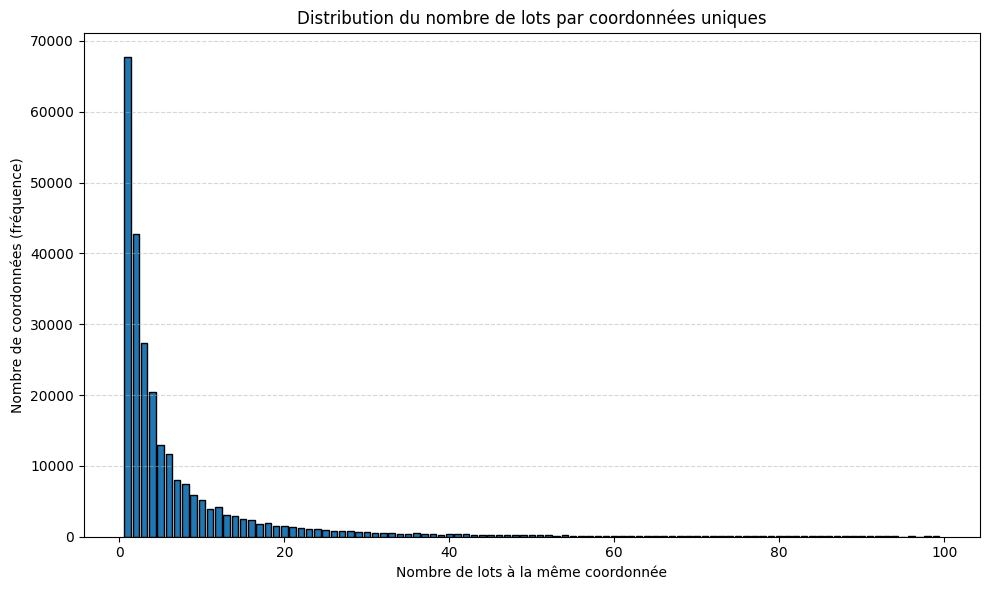

In [ ]:
# 1. Calculer la distribution : nb de coordonnées pour chaque nb de lots
counts = df_coords_uniques['nb_lots'].value_counts().sort_index()

# 2. Filtrer si nécessaire (par exemple moins de 100)
counts = counts[counts.index < 100]

# 3. Tracer l’histogramme
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, edgecolor='black')

# 4. Ajouter les titres et axes
plt.title("Distribution du nombre de lots par coordonnées uniques")
plt.xlabel("Nombre de lots à la même coordonnée")
plt.ylabel("Nombre de coordonnées (fréquence)")

# 5. Grille + affichage
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


In [58]:
distrib_nb_lots_meme_adresse = df_coords_uniques['nb_lots']
distrib_nb_lots_meme_adresse.to_csv("distrib_nb_lots_meme_adresse.csv", index=False)

In [41]:
# import geopandas as gpd
# from shapely.geometry import Point
# from shapely.strtree import STRtree

# # 1. Créer la GeoDataFrame
# gdf_lots = gpd.GeoDataFrame(
#     lots_adresses.copy(),
#     geometry=gpd.points_from_xy(lots_adresses['adr_plan_x'], lots_adresses['adr_plan_y']),
#     crs="EPSG:4326"
# )

# # 2. Reprojeter en Lambert 93 (EPSG:2154) pour les distances en mètres
# gdf_lots = gdf_lots.to_crs(epsg=2154)

# # 3. Construire la liste de géométries et l’index spatial
# geoms = gdf_lots.geometry.tolist()
# spatial_index = STRtree(geoms)

# # 4. Calculer le nombre de voisins dans un rayon de 30 m
# buffer_distance = 30  # en mètres
# counts = []

# for i, geom in enumerate(geoms):
#     # STRtree retourne ici des index entiers
#     candidate_idxs = spatial_index.query(geom.buffer(buffer_distance))
    
#     count = 0
#     for j in candidate_idxs:
#         if i == j:
#             continue  # exclure soi-même
#         if geom.distance(geoms[j]) <= buffer_distance:
#             count += 1
#     counts.append(count)

# # 5. Ajouter au GeoDataFrame
# gdf_lots["nombre_voisins_30m"] = counts

# # 6. Vérification
# print(gdf_lots[["adr_plan_x", "adr_plan_y", "nombre_voisins_30m"]].head())